In [1]:
# Project Paths
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR = PROJECT_ROOT / "Xenopus_to_Human" / "data"

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Data directory exists:", DATA_DIR.exists())

Current working directory: /Users/rwv183/Desktop/KU_Thesis_2026/Xenopus_to_Human/notebooks
Project root: /Users/rwv183/Desktop/KU_Thesis_2026
Data directory exists: True


In [2]:
# Load AnnData
import scanpy as sc
import pandas as pd
import numpy as np

adata_xeno = sc.read_h5ad(str(DATA_DIR / "adata_all.h5ad"))
adata_xeno

AnnData object with n_obs × n_vars = 75467 × 41560
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample'

In [3]:
# Extract Xenopus Gene symbols
var_df = adata_xeno.var.reset_index().rename(columns={"index": "raw_name"})
var_df["xeno_symbol"] = var_df["raw_name"].str.split("|", n=1).str[-1]

adata_xeno.var["raw_name"] = var_df["raw_name"].values
adata_xeno.var["xeno_symbol"] = var_df["xeno_symbol"].values

adata_xeno.var.head()

,raw_name,xeno_symbol
gene25011|Xelaev18004747m,gene25011|Xelaev18004747m,Xelaev18004747m
gene21250|Xetrov90028798m.L,gene21250|Xetrov90028798m.L,Xetrov90028798m.L
gene27977|Xelaev18004749m,gene27977|Xelaev18004749m,Xelaev18004749m
gene26149|Xelaev18004750m,gene26149|Xelaev18004750m,Xelaev18004750m
gene25611|Xelaev18004751m,gene25611|Xelaev18004751m,Xelaev18004751m


In [4]:
# Count number of unique Xenopus gene symbols
adata_xeno.var["xeno_symbol"].nunique()

41188

In [5]:
# Load the Xenbase ortholog mapping table
url = "https://download.xenbase.org/xenbase/GenePageReports/GeneGenomeHumanOrtho_xl9_2_chd.txt"
df = pd.read_csv(url, sep="\t", dtype=str)
df.head()

,XENBASE_GENE_ID,SYMBOL,XENBASE_GENEPAGE_ID,XENBASE_TRANSCRIPT_ID,ENTREZ_GENE_ID,MODEL_NAME,NCBI_GENE_ID,DB_ID,GENOME_ASSEMBLY,ENSEMBL,HGNC_ID,ORTHOLOG_HUMAN_SYMBOL,ORTHOLOG_HUMAN_ENTREZ
0,XB-GENE-17335793,1a11.S,XB-GENEPAGE-6538771,NaN,780751,XL-9_2-gene38603,9_2,148,XB XL Genome 9.2-gene,NaN,NaN,NaN,NaN
1,XB-GENE-6252610,42sp43.L,XB-GENEPAGE-5898341,XM_018234134,397745,XL-9_2-gene472,9_2,148,XB XL Genome 9.2-gene,NaN,NaN,NaN,NaN
2,XB-GENE-5853356,42sp50.L,XB-GENEPAGE-5853279,NaN,397889,XL-9_2-gene16313,9_2,148,XB XL Genome 9.2-gene,NaN,NaN,NaN,NaN
3,XB-GENE-952966,a1cf.L,XB-GENEPAGE-952964,XM_018224490|XM_041568482|XM_041568481,444478,XL-9_2-gene40139,9_2,148,XB XL Genome 9.2-gene,NaN,24086,A1CF,29974
4,XB-GENE-17333199,a2m.L,XB-GENEPAGE-481724,XM_041570164,108695707,XL-9_2-gene7104,9_2,148,XB XL Genome 9.2-gene,NaN,7,A2M,2


In [6]:
# Identify overlapping Xenopus Gene symbols
var_symbols = set(adata_xeno.var["xeno_symbol"].dropna().astype(str).str.strip().str.lower())
ortho_symbols = set(df["SYMBOL"].dropna().astype(str).str.strip().str.lower())

matched = var_symbols & ortho_symbols

print(f"adata unique symbols:   {len(var_symbols)}")
print(f"ortho unique symbols:   {len(ortho_symbols)}")
print(f"Matched:                {len(matched)}")

adata unique symbols:   41187
ortho unique symbols:   22980
Matched:                15984


In [7]:
# Filter the dataset for matched Xenopus-Human genes
# Build a clean var_df from adata.var_names (guaranteed)
var_df = pd.DataFrame({"raw_name": adata_xeno.var_names.astype(str)})
var_df["xeno_symbol"] = var_df["raw_name"].str.split("|", n=1).str[-1].astype(str).str.strip()
var_df["xeno_symbol_lower"] = var_df["xeno_symbol"].str.lower()

# Build a clean xenbase df2
df2 = df[["SYMBOL", "ORTHOLOG_HUMAN_SYMBOL"]].copy()
df2["SYMBOL"] = df2["SYMBOL"].astype(str).str.strip()
df2["SYMBOL_lower"] = df2["SYMBOL"].str.lower()

# Filter to matched
matched_df = var_df[var_df["xeno_symbol_lower"].isin(matched)].copy()

# Merge using lowercased key (consistent with how matched was computed)
matched_df = matched_df.merge(
    df2[["SYMBOL", "SYMBOL_lower", "ORTHOLOG_HUMAN_SYMBOL"]],
    left_on="xeno_symbol_lower",
    right_on="SYMBOL_lower",
    how="left"
)

print("matched_df rows:", matched_df.shape[0])
matched_df.head()

matched_df rows: 16252


,raw_name,xeno_symbol,xeno_symbol_lower,SYMBOL,SYMBOL_lower,ORTHOLOG_HUMAN_SYMBOL
0,gene40437|suclg1.S,suclg1.S,suclg1.s,suclg1.S,suclg1.s,SUCLG1
1,gene3136|adra1d.L,adra1d.L,adra1d.l,adra1d.L,adra1d.l,ADRA1D
2,gene65|smox.L,smox.L,smox.l,smox.L,smox.l,SMOX
3,gene9327|rnf24.L,rnf24.L,rnf24.l,rnf24.L,rnf24.l,RNF24
4,gene16290|gnrh2.L,gnrh2.L,gnrh2.l,gnrh2.L,gnrh2.l,GNRH2


In [8]:
# Inspect the data
print("First 10 rows:")
print(matched_df[["xeno_symbol", "ORTHOLOG_HUMAN_SYMBOL"]].head(10))

print("\nLast 10 rows:")
print(matched_df[["xeno_symbol", "ORTHOLOG_HUMAN_SYMBOL"]].tail(10))

First 10 rows:
  xeno_symbol ORTHOLOG_HUMAN_SYMBOL
0    suclg1.S                SUCLG1
1    adra1d.L                ADRA1D
2      smox.L                  SMOX
3     rnf24.L                 RNF24
4     gnrh2.L                 GNRH2
5       avp.L                   AVP
6     ubox5.L                 UBOX5
7     lzts3.L                 LZTS3
8      atrn.L                  ATRN
9   slc4a11.L               SLC4A11

Last 10 rows:
      xeno_symbol ORTHOLOG_HUMAN_SYMBOL
16242     srrm2.S                 SRRM2
16243     phgdh.S                 PHGDH
16244     rraga.S                 RRAGA
16245      gbp7.S                  GBP7
16246      gbp4.S                  GBP4
16247     ppil3.S                 PPIL3
16248    nif3l1.S                NIF3L1
16249    xepsin.S                   NaN
16250    rnf112.S                RNF112
16251     mfap4.S                 MFAP4


In [9]:
# Keep only rows with a valid human symbol

map_df = matched_df[["xeno_symbol", "ORTHOLOG_HUMAN_SYMBOL"]].copy()
map_df = map_df.dropna(subset=["ORTHOLOG_HUMAN_SYMBOL"])

# standardize keys/values
map_df["xeno_symbol"] = map_df["xeno_symbol"].astype(str).str.strip()
map_df["ORTHOLOG_HUMAN_SYMBOL"] = map_df["ORTHOLOG_HUMAN_SYMBOL"].astype(str).str.strip()

xeno_to_human = dict(zip(map_df["xeno_symbol"], map_df["ORTHOLOG_HUMAN_SYMBOL"]))

print("Mapping pairs (non-NA human):", len(xeno_to_human))
print(map_df.head())

Mapping pairs (non-NA human): 15783
  xeno_symbol ORTHOLOG_HUMAN_SYMBOL
0    suclg1.S                SUCLG1
1    adra1d.L                ADRA1D
2      smox.L                  SMOX
3     rnf24.L                 RNF24
4     gnrh2.L                 GNRH2


In [10]:
# Create a var table with Xenopus symbol and mapped human symbol

var_apply = pd.DataFrame({"raw_name": adata_xeno.var_names.astype(str)})
var_apply["xeno_symbol"] = var_apply["raw_name"].str.split("|", n=1).str[-1].astype(str).str.strip()

# map to human
var_apply["human_symbol"] = var_apply["xeno_symbol"].map(xeno_to_human)

print("Total features:", var_apply.shape[0])
print("Mapped to human (non-NA):", var_apply["human_symbol"].notna().sum())
var_apply.head()

Total features: 41560
Mapped to human (non-NA): 16048


,raw_name,xeno_symbol,human_symbol
0,gene25011|Xelaev18004747m,Xelaev18004747m,NaN
1,gene21250|Xetrov90028798m.L,Xetrov90028798m.L,NaN
2,gene27977|Xelaev18004749m,Xelaev18004749m,NaN
3,gene26149|Xelaev18004750m,Xelaev18004750m,NaN
4,gene25611|Xelaev18004751m,Xelaev18004751m,NaN


In [11]:
# Subset AnnData to genes with a human mapping

mapped_mask = var_apply["human_symbol"].notna().values
adata_human = adata_xeno[:, mapped_mask].copy()

# attach mapping info to var
adata_human.var["raw_name"] = var_apply.loc[mapped_mask, "raw_name"].values
adata_human.var["xeno_symbol"] = var_apply.loc[mapped_mask, "xeno_symbol"].values
adata_human.var["human_symbol"] = var_apply.loc[mapped_mask, "human_symbol"].values

print("adata_human shape (cells x mapped genes):", adata_human.shape)

adata_human shape (cells x mapped genes): (75467, 16048)


In [12]:
# Collapse duplicate human symbols by summing expression

import scipy.sparse as sp

# set var_names to human symbols temporarily
adata_human.var_names = adata_human.var["human_symbol"].astype(str)

# group columns (genes) with same human symbol
human_symbols = adata_human.var_names.to_numpy()
uniq, inv = np.unique(human_symbols, return_inverse=True)

X = adata_human.X
if not sp.issparse(X):
    X = sp.csr_matrix(X)

# build a gene-collapsing matrix: (n_genes -> n_unique_genes)
G = sp.csr_matrix(
    (np.ones_like(inv, dtype=np.float32), (np.arange(len(inv)), inv)),
    shape=(len(inv), len(uniq))
)

# collapse: cells x genes  @  genes x uniq_genes  -> cells x uniq_genes
X_collapsed = X @ G

# create collapsed AnnData
adata_human_collapsed = sc.AnnData(
    X=X_collapsed,
    obs=adata_human.obs.copy(),
    var=pd.DataFrame(index=uniq)
)

# keep provenance (optional but useful)
adata_human_collapsed.var["human_symbol"] = adata_human_collapsed.var.index

print("After collapsing duplicates:", adata_human_collapsed.shape)
print("var_names unique:", adata_human_collapsed.var_names.is_unique)

After collapsing duplicates: (75467, 11120)
var_names unique: True


In [13]:
# QC summary of mapping

qc = {
    "total_xeno_features": adata_xeno.n_vars,
    "mapped_features_pre_collapse": adata_human.n_vars,
    "unique_human_genes_post_collapse": adata_human_collapsed.n_vars,
    "cells": adata_human_collapsed.n_obs,
    "dropped_unmapped": adata_xeno.n_vars - adata_human.n_vars,
    "collapsed_duplicates": adata_human.n_vars - adata_human_collapsed.n_vars
}

qc_df = pd.DataFrame([qc])
qc_df

,total_xeno_features,mapped_features_pre_collapse,unique_human_genes_post_collapse,cells,dropped_unmapped,collapsed_duplicates
0,41560,16048,11120,75467,25512,4928


In [ ]:
qc_df.to_csv(str(DATA_DIR / "ortholog_mapping_qc.tsv"), sep="\t", index=False)

In [15]:
out_path = DATA_DIR / "adata_human_mapped.h5ad"
adata_xeno.write(str(out_path))
print("Saved:", out_path)

Saved: /Users/rwv183/Desktop/KU_Thesis_2026/Xenopus_to_Human/data/adata_human_mapped.h5ad


In [16]:
import scanpy as sc

check = sc.read_h5ad("/Users/rwv183/Desktop/KU_Thesis_2026/Xenopus_to_Human/data/adata_human_mapped.h5ad")
print(check.shape)
print(check.var_names[:10].tolist())
print(check.obs["CellType"].value_counts())

(75467, 41560)
['gene25011|Xelaev18004747m', 'gene21250|Xetrov90028798m.L', 'gene27977|Xelaev18004749m', 'gene26149|Xelaev18004750m', 'gene25611|Xelaev18004751m', 'gene30800|Xelaev18004752m', 'gene30310|Xelaev18004753m', 'gene21431|Xelaev18004754m', 'gene2020|LOC108719298', 'gene22922|Xelaev18004756m']
CellType
Early epithelial progenitor    11420
Basal                           7601
Pluripotent                     5541
Multiciliated                   2322
Goblet                          1955
Ionocyte                         961
Name: count, dtype: int64


In [ ]:
### DONE ###

In [17]:
adata_human_collapsed.obs.columns

Index(['barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph',
       'Pseudotime_Pltr', 'Differentiation Potential_Pltr',
       'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase',
       'Branch Probabilities Basal', 'Branch Probabilities Goblet',
       'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated',
       'stage_from_file', 'sample'],
      dtype='object')

In [18]:
import scipy.sparse as sp
X = adata_human_collapsed.X
print("Shape:", adata_human_collapsed.shape)
print("Sparse:", sp.issparse(X))
print("Total counts:", X.sum())
print("Any NaNs in X?", np.isnan(X.data).any() if sp.issparse(X) else np.isnan(X).any())

Shape: (75467, 11120)
Sparse: True
Total counts: 19966528.0
Any NaNs in X? False


In [19]:
print("var_names unique:", adata_human_collapsed.var_names.is_unique)
print("var_names dtype:", adata_human_collapsed.var_names.dtype)
print("Example genes:", adata_human_collapsed.var_names[:10].tolist())

var_names unique: True
var_names dtype: object
Example genes: ['A1CF', 'A2M', 'A4GNT', 'AAAS', 'AACS', 'AADAC', 'AADACL4', 'AADAT', 'AAGAB', 'AAMP']


In [20]:
# Check CellType is usable (not too many NAs) 
ct = adata_human_collapsed.obs["CellType"].astype("category")
print("Missing CellType:", ct.isna().sum())
print("Num CellTypes:", ct.nunique())
print(ct.value_counts().head(15))

Missing CellType: 45667
Num CellTypes: 6
CellType
Early epithelial progenitor    11420
Basal                           7601
Pluripotent                     5541
Multiciliated                   2322
Goblet                          1955
Ionocyte                         961
Name: count, dtype: int64


In [25]:
# Use only cells with CellType (Filter NAs)
adata_liana = adata_human_collapsed[adata_human_collapsed.obs["CellType"].notna()].copy()

# sanity
ct = adata_liana.obs["CellType"].astype("category")
print("Cells kept:", adata_liana.n_obs)
print("Missing CellType:", ct.isna().sum())
print("Num CellTypes:", ct.nunique())
print(ct.value_counts())

Cells kept: 29800
Missing CellType: 0
Num CellTypes: 6
CellType
Early epithelial progenitor    11420
Basal                           7601
Pluripotent                     5541
Multiciliated                   2322
Goblet                          1955
Ionocyte                         961
Name: count, dtype: int64


In [23]:
adata_liana.shape

(29800, 11119)

In [26]:
out_path = DATA_DIR / "adata_human_mapped_liana_ready.h5ad"
adata_liana.write(str(out_path))
print("Saved:", out_path)

Saved: /Users/rwv183/Desktop/KU_Thesis_2026/Xenopus_to_Human/data/adata_human_mapped_liana_ready.h5ad


In [22]:
import pandas as pd

mapping_summary = pd.DataFrame({
    "Stage": [
        "Xenopus genes",
        "Mapped to human ortholog",
        "Unique human genes (collapsed)"
    ],
    "Genes": [
        41560,
        16048,
        11119
    ]
})

mapping_summary

,Stage,Genes
0,Xenopus genes,41560
1,Mapped to human ortholog,16048
2,Unique human genes (collapsed),11119


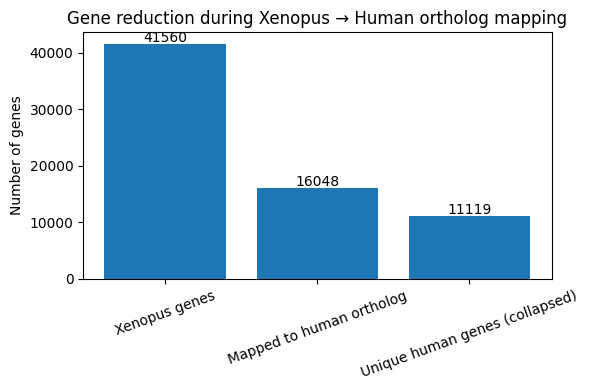

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(mapping_summary["Stage"], mapping_summary["Genes"])

plt.ylabel("Number of genes")
plt.title("Gene reduction during Xenopus → Human ortholog mapping")
plt.xticks(rotation=20)

for i, v in enumerate(mapping_summary["Genes"]):
    plt.text(i, v + 300, str(v), ha='center')

plt.tight_layout()
plt.show()

In [24]:
mapped_pct = 16048 / 41560 * 100
unique_pct = 11119 / 41560 * 100

print(f"Mapped orthologs: {mapped_pct:.1f}%")
print(f"Unique human genes after collapsing: {unique_pct:.1f}%")

Mapped orthologs: 38.6%
Unique human genes after collapsing: 26.8%
